<a href="https://colab.research.google.com/github/ssfatemi/DL-ML-Tutorial/blob/main/DL-python/16_Transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer learning in image classification
Using pretrained models and Freezing the Layers

**In this notebook we will use transfer learning and take pre-trained model from google's Tensorflow Hub and re-train that on flowers dataset. Using pre-trained model saves lot of time and computational budget for new classification problem at hand**

In [ ]:
# Install tensorflow_hub using pip install tensorflow_hub first

In [3]:
import numpy as np
import cv2

import PIL.Image as Image
import os

import matplotlib.pylab as plt

import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

**Make predictions using ready made model (without any training)**

In [4]:
import tensorflow_hub as hub
import tf_keras
IMAGE_SHAPE = (224, 224)
hub_layer = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4", input_shape=IMAGE_SHAPE + (3,))

IMAGE_SHAPE = (224, 224)

classifier = tf_keras.Sequential([
    hub.KerasLayer(hub_layer, input_shape=IMAGE_SHAPE+(3,))
])

In [14]:
tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')


'/root/.keras/datasets/ImageNetLabels.txt'

In [15]:
tf.keras.utils.get_file('ImageNetLabels.txt','https://storage.googleapis.com/download.tensorflow.org/data/ImageNetLabels.txt')
image_labels = []
with open("/root/.keras/datasets/ImageNetLabels.txt", "r") as f:
    image_labels = f.read().splitlines()
image_labels[:5]

['background', 'tench', 'goldfish', 'great white shark', 'tiger shark']

<h3 style='color:purple'>Load flowers dataset</h3>

In [22]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)
# cache_dir indicates where to download data. I specified . which means current directory
# untar true will unzip it

data_dir = data_dir + '/flower_photos'
data_dir

'./datasets/flower_photos/flower_photos'

In [23]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos/flower_photos')

In [24]:
list(data_dir.glob('*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/dandelion/16953818045_fea21c8bf8.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/14829055_2a2e646a8f_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/8533312924_ee09412645_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/479115838_0771a6cdff.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/2502627784_4486978bcf.jpg')]

In [25]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [26]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/4754734410_94d98463a5.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5863698305_04a4277401_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2197754124_5c8a146761_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9309388105_12c0b8dd54_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3705716290_cb7d803130_n.jpg')]

Read flowers images from disk into numpy array using opencv

In [28]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*')),
    'daisy': list(data_dir.glob('daisy/*')),
    'dandelion': list(data_dir.glob('dandelion/*')),
    'sunflowers': list(data_dir.glob('sunflowers/*')),
    'tulips': list(data_dir.glob('tulips/*')),
}

In [29]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [30]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/4754734410_94d98463a5.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/5863698305_04a4277401_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/2197754124_5c8a146761_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/9309388105_12c0b8dd54_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3705716290_cb7d803130_n.jpg')]

In [31]:
str(flowers_images_dict['roses'][0])

'datasets/flower_photos/flower_photos/roses/4754734410_94d98463a5.jpg'

In [33]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))
img.shape

(333, 500, 3)

In [35]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(224,224))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [36]:
X = np.array(X)
y = np.array(y)

Train test split

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

Preprocessing: scale images

In [38]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

**Make prediction using pre-trained model on new flowers dataset**

In [39]:
X[0].shape

(224, 224, 3)

In [40]:
IMAGE_SHAPE+(3,)

(224, 224, 3)

In [41]:
x0_resized = cv2.resize(X[0], IMAGE_SHAPE)
x1_resized = cv2.resize(X[1], IMAGE_SHAPE)
x2_resized = cv2.resize(X[2], IMAGE_SHAPE)

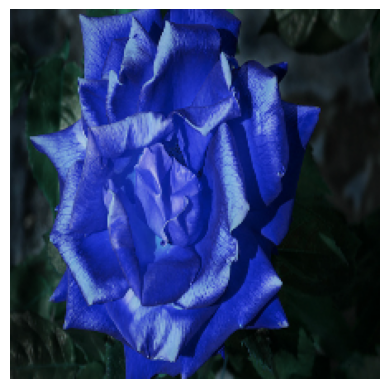

In [42]:
plt.axis('off')
plt.imshow(X[0])

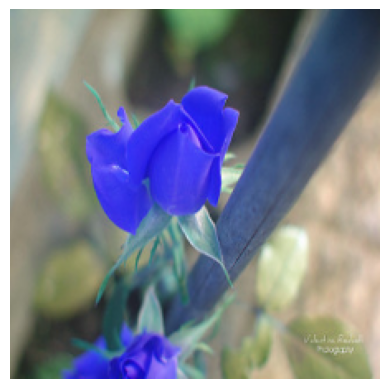

In [43]:
plt.axis('off')
plt.imshow(X[1])

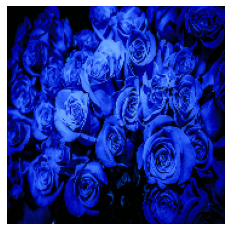

In [ ]:
plt.axis('off')
plt.imshow(X[2])

In [44]:
predicted = classifier.predict(np.array([x0_resized, x1_resized, x2_resized]))
predicted = np.argmax(predicted, axis=1)
predicted

1/1 [==============================] - 4s 4s/step


array([795, 795, 550])

In [45]:
image_labels[795]

'shower curtain'

Now take pre-trained model and retrain it using flowers images

In [5]:
feature_extractor_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model_without_top_layer = hub.KerasLayer(
    feature_extractor_model, input_shape=(224, 224, 3), trainable=False)

In [49]:
num_of_flowers = 5

model = tf_keras.Sequential([
  pretrained_model_without_top_layer,
  tf_keras.layers.Dense(num_of_flowers)
])

model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_11 (KerasLayer  (None, 1280)              2257984   
 )                                                               
                                                                 
 dense (Dense)               (None, 5)                 6405      
                                                                 
Total params: 2264389 (8.64 MB)
Trainable params: 6405 (25.02 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [1]:
model.compile(
  optimizer="adam",
  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
  metrics=['acc'])

model.fit(X_train_scaled, y_train, epochs=5)

NameError: name 'model' is not defined

In [ ]:
model.evaluate(X_test_scaled,y_test)